# Self-Study: IDA* and Recursive Best-First Search (RBFS)

**AI Module — ATU Galway**  
**Topic:** Memory-Efficient Optimal Search Algorithms  
**Prerequisites:** Lab 7 (Uninformed Search) and Lab 8 (Heuristic Search)

---

## Overview

In Lab 8, we implemented A\* — an optimal search algorithm that uses $f(n) = g(n) + h(n)$ to find the cheapest path. A\*'s main weakness is **space complexity**: it stores all discovered nodes in the OPEN and CLOSED lists, giving it $O(b^d)$ memory usage — the same as BFS.

For large search spaces, this is prohibitive. Two algorithms address this by **trading space for time**:

1. **IDA\*** (Iterative Deepening A\*): Applies the iterative deepening idea from IDDFS (Lab 7), but uses $f(n)$ as the bound instead of depth.
2. **RBFS** (Recursive Best-First Search): A recursive algorithm that keeps only the current path and its siblings in memory, using backed-up $f$-values to decide when to switch branches.

Both achieve **linear space** $O(b \cdot d)$ while preserving A\*'s optimality and completeness (with an admissible heuristic). The cost is that nodes may be regenerated multiple times.

We'll implement both from scratch and test them on the graph from a past exam paper.

---

## Setup

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import heapq
from collections import defaultdict

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 7)
plt.rcParams['figure.dpi'] = 100

---

## Part 1: The Exam Graph

We'll use the directed graph from a past exam paper. The starting node is **A** and the goal is **I**. Each node has a heuristic estimate $h(n)$ of the distance to I, and each edge has an actual cost.

This is a **directed graph** — edges go one way only (note the arrows).

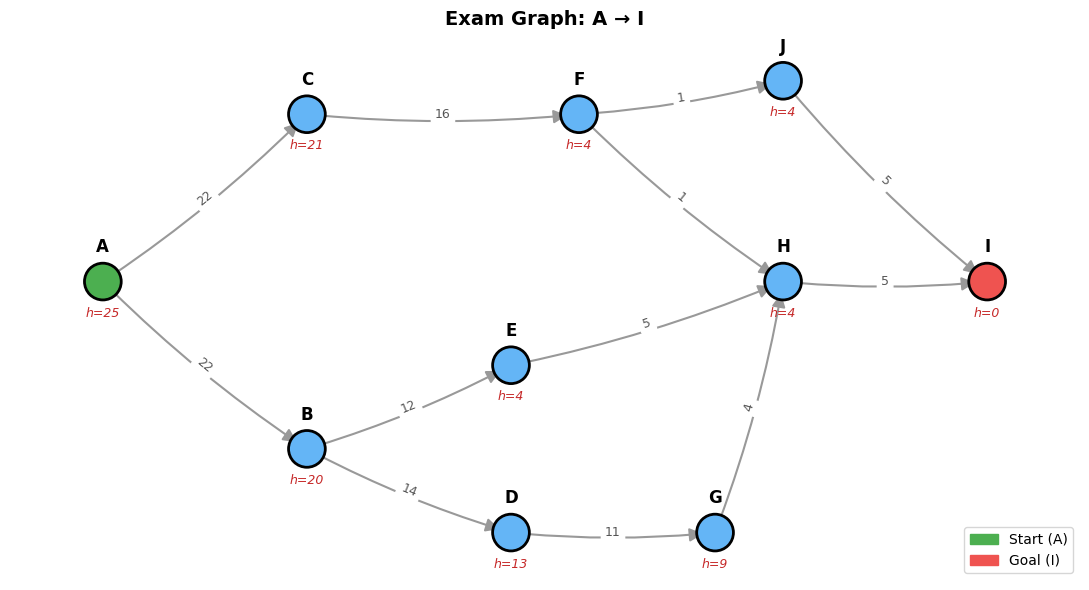

In [2]:
# Directed graph from exam paper
# Node: {neighbour: edge_cost, ...}
exam_graph = {
    'A': {'B': 22, 'C': 22},
    'B': {'D': 14, 'E': 12},
    'C': {'F': 16},
    'D': {'G': 11},
    'E': {'H': 5},
    'F': {'H': 1, 'J': 1},
    'G': {'H': 4},
    'H': {'I': 5},
    'J': {'I': 5},
    'I': {}
}

# Heuristic: estimated distance to goal I
h = {'A': 25, 'B': 20, 'C': 21, 'D': 13, 'E': 4, 'F': 4,
     'G': 9, 'H': 4, 'I': 0, 'J': 4}

# Build NetworkX directed graph for visualisation
G = nx.DiGraph()
for node, neighbors in exam_graph.items():
    for neighbor, cost in neighbors.items():
        G.add_edge(node, neighbor, weight=cost)

# Fixed positions matching the exam paper layout
pos = {
    'A': (0, 1),
    'B': (1.5, 0), 'C': (1.5, 2),
    'D': (3, -0.5), 'E': (3, 0.5),
    'F': (3.5, 2), 'G': (4.5, -0.5),
    'H': (5, 1), 'J': (5, 2.2),
    'I': (6.5, 1),
}

def draw_exam_graph(title='Exam Graph: A → I', highlight_path=None, highlight_cost=None):
    fig, ax = plt.subplots(figsize=(11, 6))
    
    node_colors = []
    for n in G.nodes():
        if n == 'A':
            node_colors.append('#4CAF50')
        elif n == 'I':
            node_colors.append('#EF5350')
        else:
            node_colors.append('#64B5F6')
    
    nx.draw_networkx_edges(G, pos, ax=ax, edge_color='#999999', width=1.5,
                           arrows=True, arrowsize=20, connectionstyle='arc3,rad=0.05')
    edge_labels = {(u, v): d['weight'] for u, v, d in G.edges(data=True)}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, ax=ax,
                                  font_size=9, font_color='#555555')
    
    if highlight_path:
        path_edges = list(zip(highlight_path[:-1], highlight_path[1:]))
        nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='#E91E63',
                               width=3.5, arrows=True, arrowsize=20, ax=ax,
                               connectionstyle='arc3,rad=0.05')
    
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors,
                           node_size=700, edgecolors='black', linewidths=2)
    
    for node, (x, y) in pos.items():
        ax.text(x, y + 0.15, node, ha='center', va='bottom',
                fontsize=12, fontweight='bold')
        ax.text(x, y - 0.15, f'h={h[node]}', ha='center', va='top',
                fontsize=9, color='#C62828', fontstyle='italic')
    
    legend_items = [
        mpatches.Patch(color='#4CAF50', label='Start (A)'),
        mpatches.Patch(color='#EF5350', label='Goal (I)'),
    ]
    if highlight_path and highlight_cost is not None:
        legend_items.append(mpatches.Patch(color='#E91E63',
                           label=f'Path: {" → ".join(highlight_path)} (cost {highlight_cost})'))
    ax.legend(handles=legend_items, loc='lower right', fontsize=10)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.show()

draw_exam_graph()

### 1.1 A\* Baseline

First, let's run A\* on this graph to establish the optimal path and cost. This is the same A\* from Lab 8.

A* result: A → B → E → H → I, cost = 44, nodes expanded = 8
A* space: O(b^d) — stores all nodes in OPEN and CLOSED


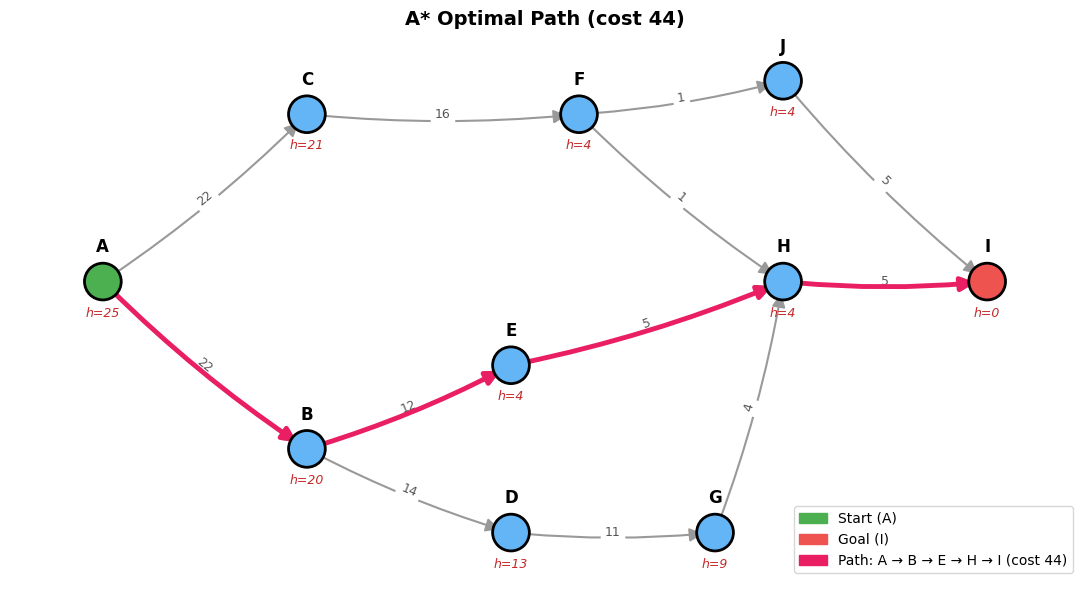

In [3]:
def a_star(graph, h, start, goal):
    """A* search (from Lab 8) for reference."""
    visited = set()
    g_costs = {start: 0}
    pq = [(h[start], 0, start, [start])]
    expanded = 0
    
    while pq:
        f, g, node, path = heapq.heappop(pq)
        if node in visited:
            continue
        visited.add(node)
        expanded += 1
        if node == goal:
            return path, g, expanded
        for neighbor, dist in graph.get(node, {}).items():
            if neighbor not in visited:
                new_g = g + dist
                if neighbor not in g_costs or new_g < g_costs[neighbor]:
                    g_costs[neighbor] = new_g
                    heapq.heappush(pq, (new_g + h[neighbor], new_g, neighbor,
                                       path + [neighbor]))
    return None, 0, expanded

astar_path, astar_cost, astar_exp = a_star(exam_graph, h, 'A', 'I')
print(f"A* result: {' → '.join(astar_path)}, cost = {astar_cost}, nodes expanded = {astar_exp}")
print(f"A* space: O(b^d) — stores all nodes in OPEN and CLOSED")

draw_exam_graph(title=f'A* Optimal Path (cost {astar_cost})',
                highlight_path=astar_path, highlight_cost=astar_cost)

---

## Part 2: IDA\* (Iterative Deepening A\*)

### 2.1 How IDA\* Works

IDA\* applies the same iterative deepening idea as IDDFS (Lab 7), but instead of increasing a **depth** limit, it increases an **$f(n)$ bound**.

**Algorithm:**
1. Set the initial bound to $h(\text{start})$ (the heuristic estimate at the root).
2. Perform a depth-first search, but **cut off** any node where $f(n) > \text{bound}$.
3. If the goal is found, return it.
4. Otherwise, set the new bound to the **smallest $f(n)$** of any node that exceeded the current bound.
5. Repeat from step 2 with the new bound.

**Key insight:** Each iteration explores all nodes with $f(n) \leq \text{bound}$. The bound increases to the next smallest $f$-value that was rejected, so each iteration makes progress.

**Properties:**
- **Complete:** Yes (with admissible heuristic).
- **Optimal:** Yes (with admissible heuristic).
- **Time:** $O(b^d)$ — same as A\*, but with regeneration overhead.
- **Space:** $O(b \cdot d)$ — only stores the current DFS path. No OPEN or CLOSED lists!

### 2.2 IDA\* Implementation

In [4]:
def ida_star(graph, h, start, goal, verbose=True):
    """
    IDA* — Iterative Deepening A*.
    
    Uses f(n) = g(n) + h(n) as a bound for depth-limited DFS.
    Each iteration increases the bound to the smallest f that exceeded
    the previous bound.
    
    Returns:
        path:           Optimal path from start to goal
        cost:           Optimal path cost
        total_expanded: Total nodes expanded across all iterations
        iterations:     Number of IDA* iterations
    """
    
    def dfs(node, g, bound, path, expanded):
        """DFS with f-bound cutoff. Returns (min_exceeded_f, path_or_None)."""
        f = g + h[node]
        
        if f > bound:
            return f, None, expanded  # Cutoff — return the f that exceeded
        
        if node == goal:
            return f, path, expanded  # Goal found!
        
        expanded[0] += 1
        min_exceeded = float('inf')
        
        for neighbor, dist in sorted(graph.get(node, {}).items()):
            if neighbor not in set(path):  # Cycle check on current path only
                new_g = g + dist
                t, result, expanded = dfs(neighbor, new_g, bound,
                                          path + [neighbor], expanded)
                if result is not None:
                    return t, result, expanded  # Goal found deeper
                if t < min_exceeded:
                    min_exceeded = t  # Track smallest f that exceeded bound
        
        return min_exceeded, None, expanded
    
    bound = h[start]
    total_expanded = 0
    iteration = 0
    
    if verbose:
        print(f"IDA* Search: {start} → {goal}")
        print(f"{'Iter':>4}  {'Bound':>6}  {'Expanded':>9}  {'Result'}")
        print("-" * 55)
    
    while True:
        iteration += 1
        expanded = [0]  # Mutable counter for recursion
        
        t, result, expanded = dfs(start, 0, bound, [start], expanded)
        total_expanded += expanded[0]
        
        if verbose:
            if result:
                print(f"{iteration:>4}  {bound:>6}  {expanded[0]:>9}  "
                      f"FOUND: {' → '.join(result)} (cost {t})")
            else:
                print(f"{iteration:>4}  {bound:>6}  {expanded[0]:>9}  "
                      f"Not found, next bound = {t}")
        
        if result is not None:
            return result, t, total_expanded, iteration
        
        if t == float('inf'):
            return None, 0, total_expanded, iteration  # No solution
        
        bound = t  # Increase bound to next threshold

### 2.3 Running IDA\* on the Exam Graph

IDA* Search: A → I
Iter   Bound   Expanded  Result
-------------------------------------------------------
   1      25          1  Not found, next bound = 42
   2      42          3  Not found, next bound = 43
   3      43          8  Not found, next bound = 44
   4      44          4  FOUND: A → B → E → H → I (cost 44)

Optimal path: A → B → E → H → I
Optimal cost: 44
Total nodes expanded: 16 (across 4 iterations)
Space used: O(b·d) — only the current path (max depth 4 nodes)

Compare with A*: expanded 8 nodes but used O(b^d) space


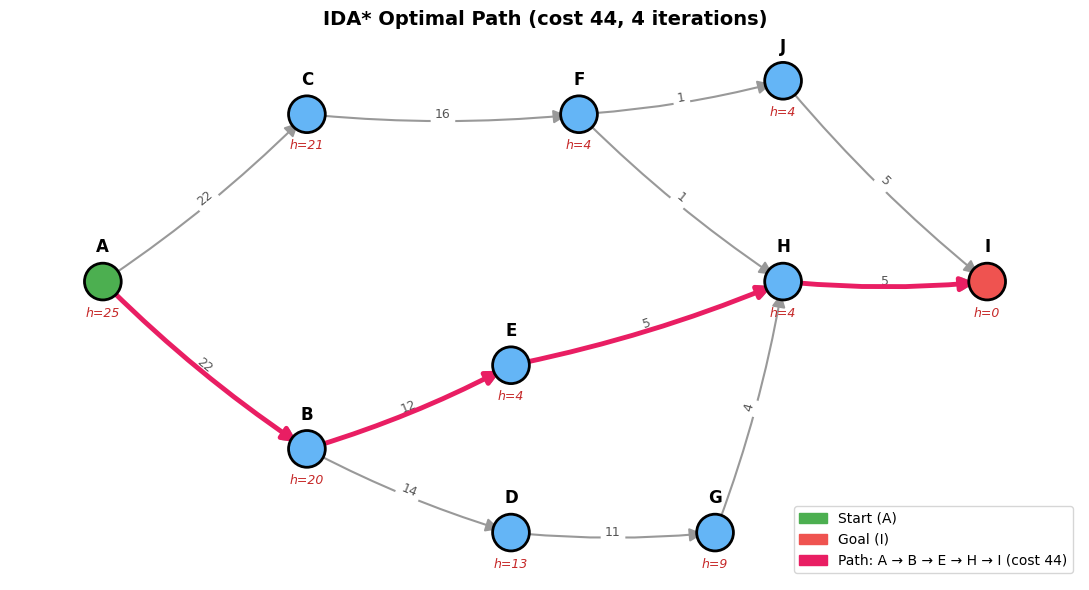

In [5]:
ida_path, ida_cost, ida_exp, ida_iters = ida_star(exam_graph, h, 'A', 'I')

print(f"\nOptimal path: {' → '.join(ida_path)}")
print(f"Optimal cost: {ida_cost}")
print(f"Total nodes expanded: {ida_exp} (across {ida_iters} iterations)")
print(f"Space used: O(b·d) — only the current path (max depth {len(ida_path)-1} nodes)")
print(f"\nCompare with A*: expanded {astar_exp} nodes but used O(b^d) space")

draw_exam_graph(title=f'IDA* Optimal Path (cost {ida_cost}, {ida_iters} iterations)',
                highlight_path=ida_path, highlight_cost=ida_cost)

### 2.4 Understanding the IDA\* Iterations

Let's trace what happens at each iteration in detail.

In [6]:
def ida_star_detailed(graph, h, start, goal):
    """IDA* with detailed per-node tracing."""
    
    def dfs(node, g, bound, path, depth, trace):
        f = g + h[node]
        indent = "  " * depth
        
        if f > bound:
            trace.append(f"{indent}→ {node}: g={g}, h={h[node]}, f={f} > bound={bound} — CUTOFF")
            return f, None
        
        trace.append(f"{indent}→ {node}: g={g}, h={h[node]}, f={f} ≤ bound={bound}")
        
        if node == goal:
            trace.append(f"{indent}  ** GOAL FOUND **")
            return f, path
        
        min_exceeded = float('inf')
        for neighbor, dist in sorted(graph.get(node, {}).items()):
            if neighbor not in set(path):
                t, result = dfs(neighbor, g + dist, bound,
                               path + [neighbor], depth + 1, trace)
                if result is not None:
                    return t, result
                if t < min_exceeded:
                    min_exceeded = t
        
        return min_exceeded, None
    
    bound = h[start]
    iteration = 0
    
    while True:
        iteration += 1
        trace = []
        t, result = dfs(start, 0, bound, [start], 0, trace)
        
        print(f"\n{'='*60}")
        print(f"Iteration {iteration}: bound = {bound}")
        print(f"{'='*60}")
        for line in trace:
            print(line)
        
        if result is not None:
            return result, t
        if t == float('inf'):
            return None, 0
        
        print(f"\nSmallest f exceeding bound: {t} → new bound = {t}")
        bound = t

ida_detail_path, ida_detail_cost = ida_star_detailed(exam_graph, h, 'A', 'I')
print(f"\nResult: {' → '.join(ida_detail_path)}, cost = {ida_detail_cost}")


Iteration 1: bound = 25
→ A: g=0, h=25, f=25 ≤ bound=25
  → B: g=22, h=20, f=42 > bound=25 — CUTOFF
  → C: g=22, h=21, f=43 > bound=25 — CUTOFF

Smallest f exceeding bound: 42 → new bound = 42

Iteration 2: bound = 42
→ A: g=0, h=25, f=25 ≤ bound=42
  → B: g=22, h=20, f=42 ≤ bound=42
    → D: g=36, h=13, f=49 > bound=42 — CUTOFF
    → E: g=34, h=4, f=38 ≤ bound=42
      → H: g=39, h=4, f=43 > bound=42 — CUTOFF
  → C: g=22, h=21, f=43 > bound=42 — CUTOFF

Smallest f exceeding bound: 43 → new bound = 43

Iteration 3: bound = 43
→ A: g=0, h=25, f=25 ≤ bound=43
  → B: g=22, h=20, f=42 ≤ bound=43
    → D: g=36, h=13, f=49 > bound=43 — CUTOFF
    → E: g=34, h=4, f=38 ≤ bound=43
      → H: g=39, h=4, f=43 ≤ bound=43
        → I: g=44, h=0, f=44 > bound=43 — CUTOFF
  → C: g=22, h=21, f=43 ≤ bound=43
    → F: g=38, h=4, f=42 ≤ bound=43
      → H: g=39, h=4, f=43 ≤ bound=43
        → I: g=44, h=0, f=44 > bound=43 — CUTOFF
      → J: g=39, h=4, f=43 ≤ bound=43
        → I: g=44, h=0, f=44 > boun

### 2.5 When Does IDA\* Regenerate Many Nodes?

IDA\* regenerates nodes when the bound increases by small amounts, causing many iterations that each re-explore most of the tree. This happens when there are **many distinct $f(n)$ values** — each iteration only captures a few new nodes.

On our exam graph, the bounds were 25 → 42 → 43 → 44, so most iterations explored substantially different parts of the tree. On graphs where $f$-values are more densely packed (e.g., many values between 40 and 45), IDA\* would regenerate more aggressively.

> **Key trade-off:** IDA\* uses $O(b \cdot d)$ space (vs A\*'s $O(b^d)$) but may expand more nodes overall due to regeneration. For problems where memory is the bottleneck (e.g., 15-puzzle, 24-puzzle), this trade-off is worth it.

---

## Part 3: Recursive Best-First Search (RBFS)

### 3.1 How RBFS Works

RBFS is a more sophisticated approach to memory-efficient optimal search. Like IDA\*, it uses linear space, but it's smarter about when to switch between branches.

**Core idea:** RBFS explores the current best path using recursion. When the current path's $f$-value exceeds the **next best alternative** (the best $f$-value among sibling branches), RBFS:
1. **Suspends** the current path by backing up the best $f$-value found in that subtree to the parent.
2. **Switches** to the alternative branch.
3. Later, if the alternative turns out worse, it can **return** to the original branch (regenerating it).

RBFS keeps track of two values for each node:
- $f(n) = g(n) + h(n)$: the standard evaluation.
- $F(n)$: the **backed-up** value — the best $f$ found in $n$'s subtree during a previous exploration. If $n$ has never been expanded, $F(n) = f(n)$. If $n$ was expanded and then suspended, $F(n)$ remembers how good the subtree was.

**Properties:**
- **Complete:** Yes (with admissible heuristic).
- **Optimal:** Yes (with admissible heuristic).
- **Time:** Depends on how often nodes are regenerated — can be worse than IDA\*.
- **Space:** $O(b \cdot d)$ — stores only the current path and its siblings at each level.

### 3.2 RBFS Implementation

In [7]:
def rbfs(graph, h, start, goal, verbose=True):
    """
    Recursive Best-First Search.
    
    Explores the best path recursively, switching to alternatives when
    the current path's f-value exceeds the best sibling's f-value.
    
    Returns:
        path:     Optimal path from start to goal
        cost:     Optimal path cost
        expanded: Number of node expansions
    """
    expanded = [0]
    
    def _rbfs(node, g, F_node, f_limit, path, depth):
        """
        Recursive search from node.
        
        Parameters:
            node:    Current node
            g:       Cost from start to node
            F_node:  Backed-up F-value for this node
            f_limit: Maximum f-value allowed (from best alternative)
            path:    Current path
            depth:   Current depth (for tracing)
        
        Returns:
            best_f:  The backed-up f-value for this subtree
            result:  Path to goal, or None
        """
        f = g + h[node]
        
        # Use backed-up value if node was previously explored
        F_current = max(F_node, f) if F_node > f else f
        
        if F_current > f_limit:
            return F_current, None
        
        if node == goal:
            return F_current, path
        
        # Generate children
        children = []
        for neighbor, dist in graph.get(node, {}).items():
            if neighbor not in set(path):
                child_g = g + dist
                child_f = child_g + h[neighbor]
                # Inherit backed-up value if parent was previously explored
                child_F = max(F_current, child_f) if f < F_current else child_f
                children.append([child_F, neighbor, child_g, path + [neighbor]])
        
        if not children:
            return float('inf'), None  # Dead end
        
        children.sort()  # Sort by F-value
        
        while children[0][0] <= f_limit:
            expanded[0] += 1
            best = children[0]
            
            # f-limit for best child = min(current f_limit, second-best F)
            if len(children) > 1:
                alternative = children[1][0]
            else:
                alternative = f_limit
            
            if verbose:
                indent = "  " * depth
                alt_str = f", alternative={alternative}" if len(children) > 1 else ""
                print(f"{indent}Expand {best[1]}: F={best[0]}, "
                      f"f_limit={min(f_limit, alternative)}{alt_str}")
            
            # Recurse into best child
            result_F, result_path = _rbfs(best[1], best[2], best[0],
                                          min(f_limit, alternative),
                                          best[3], depth + 1)
            
            # Back up the result into the child's F-value
            best[0] = result_F
            
            if result_path is not None:
                return result_F, result_path
            
            children.sort()  # Re-sort after updating F
        
        return children[0][0], None
    
    if verbose:
        print(f"RBFS Search: {start} → {goal}")
        print("-" * 60)
    
    f_start = h[start]
    result_F, result_path = _rbfs(start, 0, f_start, float('inf'), [start], 0)
    
    if result_path:
        cost = sum(graph[result_path[i]][result_path[i+1]]
                   for i in range(len(result_path) - 1))
        return result_path, cost, expanded[0]
    return None, 0, expanded[0]

### 3.3 Running RBFS on the Exam Graph

RBFS Search: A → I
------------------------------------------------------------
Expand B: F=42, f_limit=43, alternative=43
  Expand E: F=38, f_limit=43, alternative=49
    Expand H: F=43, f_limit=43
Expand C: F=43, f_limit=44, alternative=44
  Expand F: F=42, f_limit=44
    Expand H: F=43, f_limit=43, alternative=43
    Expand J: F=43, f_limit=44, alternative=44
      Expand I: F=44, f_limit=44

Optimal path: A → C → F → J → I
Optimal cost: 44
Nodes expanded: 8
Space used: O(b·d) — current path + siblings at each level


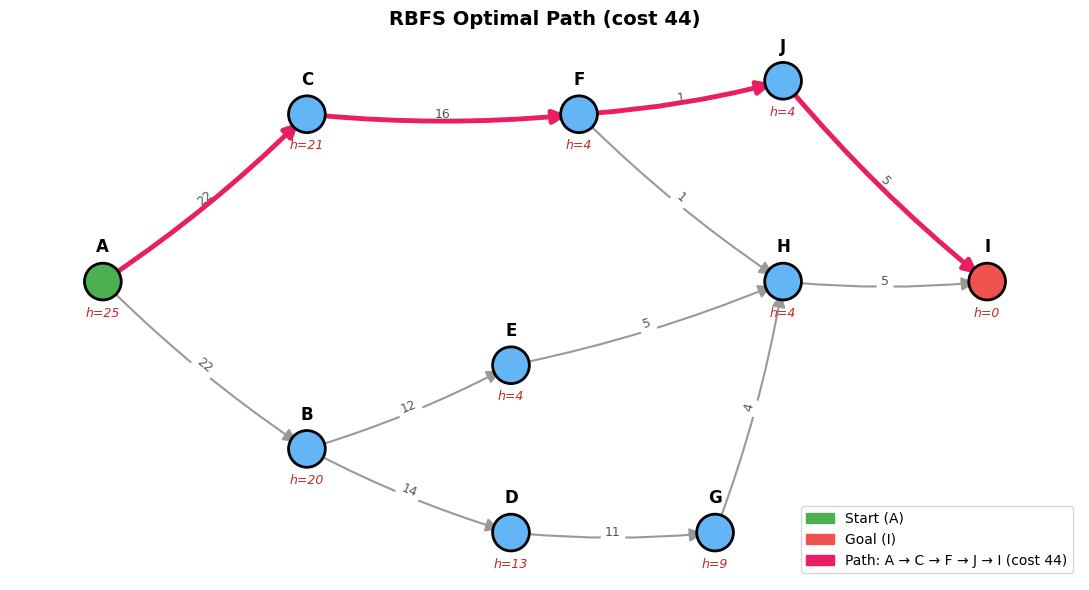

In [8]:
rbfs_path, rbfs_cost, rbfs_exp = rbfs(exam_graph, h, 'A', 'I')

print(f"\nOptimal path: {' → '.join(rbfs_path)}")
print(f"Optimal cost: {rbfs_cost}")
print(f"Nodes expanded: {rbfs_exp}")
print(f"Space used: O(b·d) — current path + siblings at each level")

draw_exam_graph(title=f'RBFS Optimal Path (cost {rbfs_cost})',
                highlight_path=rbfs_path, highlight_cost=rbfs_cost)

### 3.4 Understanding RBFS's Backed-Up Values

The key to RBFS is the **$F$-value** that gets backed up when a subtree is suspended. When RBFS abandons a branch because its $f$-value exceeds the alternative, it stores the best $f$ found in that branch. This means when it returns to that branch later, it knows exactly how good the branch was — it doesn't have to re-explore to discover this.

This is RBFS's advantage over IDA\*: IDA\* forgets everything between iterations and must rediscover $f$-values from scratch. RBFS retains this information in the backed-up $F$-values along the current path, allowing it to make better decisions about which branch to explore next.

---

## Part 4: Comparison

### 4.1 A\*, IDA\*, and RBFS Side by Side

In [9]:
# Run all three without verbose output
ida_path2, ida_cost2, ida_exp2, ida_iters2 = ida_star(exam_graph, h, 'A', 'I', verbose=False)
rbfs_path2, rbfs_cost2, rbfs_exp2 = rbfs(exam_graph, h, 'A', 'I', verbose=False)

print("Comparison: A* vs IDA* vs RBFS on the Exam Graph (A → I)")
print("=" * 70)
print(f"{'Algorithm':<12} {'Path':<25} {'Cost':>5} {'Expanded':>9} {'Space':>12}")
print("-" * 70)
print(f"{'A*':<12} {' → '.join(astar_path):<25} {astar_cost:>5} {astar_exp:>9} {'O(b^d)':>12}")
print(f"{'IDA*':<12} {' → '.join(ida_path2):<25} {ida_cost2:>5} {ida_exp2:>9} {'O(b·d)':>12}")
print(f"{'RBFS':<12} {' → '.join(rbfs_path2):<25} {rbfs_cost2:>5} {rbfs_exp2:>9} {'O(b·d)':>12}")
print()
print("Notes:")
print(f"  IDA* required {ida_iters2} iterations (bounds: 25 → 42 → 43 → 44)")
print(f"  IDA* expanded {ida_exp2} nodes total ({ida_exp2 - astar_exp} more than A* due to regeneration)")
print(f"  All three find optimal cost {astar_cost}")
if astar_path != ida_path2 or astar_path != rbfs_path2:
    print(f"  Different algorithms may find different optimal paths (same cost, different routes)")

Comparison: A* vs IDA* vs RBFS on the Exam Graph (A → I)
Algorithm    Path                       Cost  Expanded        Space
----------------------------------------------------------------------
A*           A → B → E → H → I            44         8       O(b^d)
IDA*         A → B → E → H → I            44        16       O(b·d)
RBFS         A → C → F → J → I            44         8       O(b·d)

Notes:
  IDA* required 4 iterations (bounds: 25 → 42 → 43 → 44)
  IDA* expanded 16 nodes total (8 more than A* due to regeneration)
  All three find optimal cost 44
  Different algorithms may find different optimal paths (same cost, different routes)


### 4.2 Properties Summary

| Property | A\* | IDA\* | RBFS |
|----------|-----|-------|------|
| **Complete** | Yes | Yes | Yes |
| **Optimal** | Yes | Yes | Yes |
| **Time** | $O(b^d)$ | $O(b^d)$ + regeneration | $O(b^d)$ + regeneration |
| **Space** | $O(b^d)$ | $O(b \cdot d)$ | $O(b \cdot d)$ |
| **OPEN/CLOSED lists** | Yes | No | No |
| **Regenerates nodes** | No | Yes (every iteration) | Yes (when switching branches) |
| **Best for** | Small/medium problems | Large problems, few distinct $f$-values | Large problems, many distinct $f$-values |

> **When to use which:**
> - **A\*** when memory is not a constraint — it's the most efficient in terms of node expansions.
> - **IDA\*** when memory is tight and there are relatively few distinct $f(n)$ values (so each iteration captures many new nodes). Common for tile puzzles.
> - **RBFS** when memory is tight and there are many distinct $f(n)$ values (where IDA\* would have excessive regeneration overhead). RBFS outperforms IDA\* in these cases because it retains backed-up $F$-values.

---

## Part 5: Practice Exercises

These exercises are somewhat similar to the types of questions you may encounter in the Moodle assessment.

### Exercise 1: A\* Trace

Using the exam graph above, produce a complete A\* trace showing the OPEN and CLOSED lists at each step. For each node expanded, show $g(n)$, $h(n)$, and $f(n)$.

*Hint: Use the `a_star` function from Lab 8 with tracing enabled, or trace by hand and verify with the code.*

In [10]:
# Exercise 1: A* trace for self-checking
def a_star_traced(graph, h, start, goal):
    visited = set()
    g_costs = {start: 0}
    pq = [(h[start], 0, start, [start])]
    expanded = 0
    
    print(f"A* Trace: {start} → {goal}")
    print(f"{'Step':>4}  {'Visit':>5}  {'g':>4}  {'h':>4}  {'f':>4}  {'OPEN (node: f)':<40} {'CLOSED'}")
    print("-" * 95)
    
    while pq:
        f, g, node, path = heapq.heappop(pq)
        if node in visited:
            continue
        visited.add(node)
        expanded += 1
        
        for neighbor, dist in graph.get(node, {}).items():
            if neighbor not in visited:
                new_g = g + dist
                if neighbor not in g_costs or new_g < g_costs[neighbor]:
                    g_costs[neighbor] = new_g
                    heapq.heappush(pq, (new_g + h[neighbor], new_g, neighbor,
                                       path + [neighbor]))
        
        # Build OPEN display (deduplicated)
        open_best = {}
        for f_, g_, n_, _ in pq:
            if n_ not in visited:
                if n_ not in open_best or f_ < open_best[n_]:
                    open_best[n_] = f_
        open_str = ', '.join(f"{n}:{f}" for n, f in sorted(open_best.items(), key=lambda x: x[1]))
        closed_str = ', '.join(sorted(visited))
        
        print(f"{expanded:>4}  {node:>5}  {g:>4}  {h[node]:>4}  {f:>4}  {open_str:<40} {closed_str}")
        
        if node == goal:
            print(f"\nPath: {' → '.join(path)}, Cost: {g}")
            return path, g
    return None, 0

a_star_traced(exam_graph, h, 'A', 'I')

A* Trace: A → I
Step  Visit     g     h     f  OPEN (node: f)                           CLOSED
-----------------------------------------------------------------------------------------------
   1      A     0    25    25  B:42, C:43                               A
   2      B    22    20    42  E:38, C:43, D:49                         A, B
   3      E    34     4    38  C:43, H:43, D:49                         A, B, E
   4      C    22    21    43  F:42, H:43, D:49                         A, B, C, E
   5      F    38     4    42  H:43, J:43, D:49                         A, B, C, E, F
   6      H    39     4    43  J:43, I:44, D:49                         A, B, C, E, F, H
   7      J    39     4    43  I:44, D:49                               A, B, C, E, F, H, J
   8      I    44     0    44  D:49                                     A, B, C, E, F, H, I, J

Path: A → B → E → H → I, Cost: 44


(['A', 'B', 'E', 'H', 'I'], 44)

### Exercise 2: IDA\* by Hand

Trace IDA\* on the exam graph by hand. For each iteration:
1. What is the $f$-bound?
2. Which nodes are explored (within the bound)?
3. Which nodes are cut off (exceed the bound)?
4. What is the next bound?

*Verify your answer using the detailed trace above (Exercise 2.4).*

### Exercise 3: Admissibility Check

For each node in the exam graph, verify that the heuristic is admissible: $h(n) \leq h^*(n)$.

In [11]:
# Exercise 3: Verify admissibility
print("Admissibility Check: h(n) ≤ h*(n) for all nodes")
print("=" * 55)

# Find actual shortest distance from each node to I
for node in sorted(exam_graph.keys()):
    path, cost, _ = a_star(exam_graph, h, node, 'I')
    if path:
        admissible = h[node] <= cost
        print(f"  {node}: h={h[node]:>3}, h*={cost:>3}, "
              f"h ≤ h*? {admissible} {'✓' if admissible else '✗'}")
    else:
        print(f"  {node}: no path to I")

Admissibility Check: h(n) ≤ h*(n) for all nodes
  A: h= 25, h*= 44, h ≤ h*? True ✓
  B: h= 20, h*= 22, h ≤ h*? True ✓
  C: h= 21, h*= 22, h ≤ h*? True ✓
  D: h= 13, h*= 20, h ≤ h*? True ✓
  E: h=  4, h*= 10, h ≤ h*? True ✓
  F: h=  4, h*=  6, h ≤ h*? True ✓
  G: h=  9, h*=  9, h ≤ h*? True ✓
  H: h=  4, h*=  5, h ≤ h*? True ✓
  I: h=  0, h*=  0, h ≤ h*? True ✓
  J: h=  4, h*=  5, h ≤ h*? True ✓


### Exercise 4: Consistency Check

Verify that the heuristic is consistent: $h(n) \leq c(n, n') + h(n')$ for every edge.

In [12]:
# Exercise 4: Verify consistency
print("Consistency Check: h(n) ≤ c(n,n') + h(n') for all edges")
print("=" * 60)

all_consistent = True
for node, neighbors in exam_graph.items():
    for neighbor, cost in neighbors.items():
        satisfied = h[node] <= cost + h[neighbor]
        if not satisfied:
            all_consistent = False
        print(f"  h({node})={h[node]} ≤ c({node},{neighbor})={cost} + h({neighbor})={h[neighbor]} "
              f"= {cost + h[neighbor]}? {satisfied} {'✓' if satisfied else '✗'}")

print(f"\nHeuristic is {'consistent' if all_consistent else 'NOT consistent'}.")

Consistency Check: h(n) ≤ c(n,n') + h(n') for all edges
  h(A)=25 ≤ c(A,B)=22 + h(B)=20 = 42? True ✓
  h(A)=25 ≤ c(A,C)=22 + h(C)=21 = 43? True ✓
  h(B)=20 ≤ c(B,D)=14 + h(D)=13 = 27? True ✓
  h(B)=20 ≤ c(B,E)=12 + h(E)=4 = 16? False ✗
  h(C)=21 ≤ c(C,F)=16 + h(F)=4 = 20? False ✗
  h(D)=13 ≤ c(D,G)=11 + h(G)=9 = 20? True ✓
  h(E)=4 ≤ c(E,H)=5 + h(H)=4 = 9? True ✓
  h(F)=4 ≤ c(F,H)=1 + h(H)=4 = 5? True ✓
  h(F)=4 ≤ c(F,J)=1 + h(J)=4 = 5? True ✓
  h(G)=9 ≤ c(G,H)=4 + h(H)=4 = 8? False ✗
  h(H)=4 ≤ c(H,I)=5 + h(I)=0 = 5? True ✓
  h(J)=4 ≤ c(J,I)=5 + h(I)=0 = 5? True ✓

Heuristic is NOT consistent.


### Exercise 5: What If the Heuristic Changes?

Consider changing $h(E)$ from 4 to 15. Would the heuristic still be admissible? Would it still be consistent? How would this affect A\*, IDA\*, and RBFS?

*Try it with the code and observe what changes.*

In [13]:
# Exercise 5: Modified heuristic
h_modified = dict(h)
h_modified['E'] = 15  # Change h(E) from 4 to 15

print("Modified heuristic: h(E) = 15 (was 4)")
print()

# Check admissibility for E
path_e, cost_e, _ = a_star(exam_graph, h, 'E', 'I')
print(f"Actual cost E → I: {cost_e}")
print(f"h(E) = 15, admissible? {15 <= cost_e} (h(E) ≤ h*(E) = {cost_e})")
print()

# Run A* with modified heuristic
astar_mod_path, astar_mod_cost, astar_mod_exp = a_star(exam_graph, h_modified, 'A', 'I')
print(f"A* with modified h: {' → '.join(astar_mod_path)}, cost = {astar_mod_cost}, "
      f"expanded = {astar_mod_exp}")
print(f"A* with original h: {' → '.join(astar_path)}, cost = {astar_cost}, "
      f"expanded = {astar_exp}")
if astar_mod_cost == astar_cost:
    print("Same optimal cost found by luck (A* still optimal despite non-admissible h at E), "
          "but the guarantee is broken.")
else:
    print(f"DIFFERENT cost! Modified h led to suboptimal result.")

Modified heuristic: h(E) = 15 (was 4)

Actual cost E → I: 10
h(E) = 15, admissible? False (h(E) ≤ h*(E) = 10)

A* with modified h: A → C → F → H → I, cost = 44, expanded = 7
A* with original h: A → B → E → H → I, cost = 44, expanded = 8
Same optimal cost found by luck (A* still optimal despite non-admissible h at E), but the guarantee is broken.


---

## Summary

In this notebook, we:

1. **Implemented IDA\*** from scratch — iterative deepening with an $f(n)$ bound instead of a depth limit. Uses $O(b \cdot d)$ space by eliminating OPEN and CLOSED lists.

2. **Implemented RBFS** from scratch — recursive best-first search that tracks backed-up $F$-values to efficiently switch between branches. Also uses $O(b \cdot d)$ space.

3. **Compared** A\*, IDA\*, and RBFS on the same graph: all find the optimal solution, but with different space/time trade-offs.

4. **Practised** exam-style exercises: A\* traces, admissibility and consistency checks, and analysing the effect of heuristic changes.

**Key takeaways:**
- A\*'s $O(b^d)$ space is its main weakness for large problems.
- IDA\* and RBFS reduce space to $O(b \cdot d)$ by trading space for time (node regeneration).
- IDA\* is simpler and works well when few distinct $f$-values exist.
- RBFS is more complex but outperforms IDA\* when many distinct $f$-values cause excessive regeneration.
- With an admissible heuristic, all three algorithms are optimal and complete.